In [1]:
pip install lightgbm xgboost scikit-learn pandas numpy matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

import matplotlib.pyplot as plt

In [3]:
# Load data
df = pd.read_csv("../data/processed/final_dataset.csv") 

print(df.head())
print(df.columns)


             timestamp  load_actual  temperature  humidity  dew_point  \
0  2014-12-31 23:00:00      22734.0          7.5      81.0        4.5   
1  2015-01-01 00:00:00      22734.0          7.3      81.0        4.2   
2  2015-01-01 01:00:00      22734.0          7.0      81.0        3.9   
3  2015-01-01 02:00:00      21286.0          6.8      81.0        3.7   
4  2015-01-01 03:00:00      20264.0          6.9      79.0        3.5   

   solar_generation  wind_generation  
0              50.0           5461.0  
1              50.0           5461.0  
2              50.0           5461.0  
3              50.0           5238.0  
4              42.0           4935.0  
Index(['timestamp', 'load_actual', 'temperature', 'humidity', 'dew_point',
       'solar_generation', 'wind_generation'],
      dtype='object')


In [4]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp')

# Create useful time-based features
df['year'] = df['timestamp'].dt.year
df['month'] = df['timestamp'].dt.month
df['day'] = df['timestamp'].dt.day
df['hour'] = df['timestamp'].dt.hour
df['dayofweek'] = df['timestamp'].dt.dayofweek


In [5]:
target_col = 'load_actual'   

feature_cols = [
    'temperature',           
    'year', 'month', 'day', 'hour', 'dayofweek'
]

X = df[feature_cols]
y = df[target_col]

In [6]:
test_size_ratio = 0.2   # last 20% as test
split_index = int(len(df) * (1 - test_size_ratio))

X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

print("Train size:", X_train.shape, "Test size:", X_test.shape)

Train size: (70120, 6) Test size: (17530, 6)


In [7]:
import lightgbm as lgb
from lightgbm import LGBMRegressor, early_stopping, log_evaluation

lgb_model = LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    eval_metric='l2',
    callbacks=[
        early_stopping(stopping_rounds=50),
        log_evaluation(period=10)
    ]
)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001664 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 336
[LightGBM] [Info] Number of data points in the train set: 70120, number of used features: 6
[LightGBM] [Info] Start training from score 28699.244794
Training until validation scores don't improve for 50 rounds
[10]	valid_0's l2: 1.07852e+07
[20]	valid_0's l2: 6.53973e+06
[30]	valid_0's l2: 4.45766e+06
[40]	valid_0's l2: 3.5293e+06
[50]	valid_0's l2: 3.03815e+06
[60]	valid_0's l2: 2.81933e+06
[70]	valid_0's l2: 2.63604e+06
[80]	valid_0's l2: 2.57528e+06
[90]	valid_0's l2: 2.50076e+06
[100]	valid_0's l2: 2.48114e+06
[110]	valid_0's l2: 2.42029e+06
[120]	valid_0's l2: 2.36124e+06
[130]	valid_0's l2: 2.35328e+06
[140]	valid_0's l2: 2.30693e+06
[150]	valid_0's l2: 2.27312e+06
[160]	valid_0's l2: 2.26696e+06
[170]	valid_0's l2: 2.25286e+

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,1000
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [8]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import lightgbm as lgb
from lightgbm import LGBMRegressor, early_stopping, log_evaluation

import matplotlib.pyplot


In [9]:
# Load CSV
df = pd.read_csv('../data/processed/final_dataset.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp')

# Add time features
df['year'] = df['timestamp'].dt.year
df['month'] = df['timestamp'].dt.month
df['day'] = df['timestamp'].dt.day
df['hour'] = df['timestamp'].dt.hour
df['dayofweek'] = df['timestamp'].dt.dayofweek

# Select features
feature_cols = ['temperature', 'year', 'month', 'day', 'hour', 'dayofweek']
target_col = 'load_actual' 

X = df[feature_cols]
y = df[target_col]


In [10]:
# Time-based split
test_ratio = 0.2
split_index = int(len(df) * (1 - test_ratio))

X_train = X.iloc[:split_index]
X_test  = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test  = y.iloc[split_index:]


In [11]:
lgb_model = LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    eval_metric='l2',
    callbacks=[
        early_stopping(stopping_rounds=50),  
        log_evaluation(period=10)             
    ]
)

print("Model trained successfully!")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000639 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 336
[LightGBM] [Info] Number of data points in the train set: 70120, number of used features: 6
[LightGBM] [Info] Start training from score 28699.244794
Training until validation scores don't improve for 50 rounds
[10]	valid_0's l2: 1.07852e+07
[20]	valid_0's l2: 6.53973e+06
[30]	valid_0's l2: 4.45766e+06
[40]	valid_0's l2: 3.5293e+06
[50]	valid_0's l2: 3.03815e+06
[60]	valid_0's l2: 2.81933e+06
[70]	valid_0's l2: 2.63604e+06
[80]	valid_0's l2: 2.57528e+06
[90]	valid_0's l2: 2.50076e+06
[100]	valid_0's l2: 2.48114e+06
[110]	valid_0's l2: 2.42029e+06
[120]	valid_0's l2: 2.36124e+06
[130]	valid_0's l2: 2.35328e+06
[140]	valid_0's l2: 2.30693e+06
[150]	valid_0's l2: 2.27312e+06
[160]	valid_0's l2: 2.26696e+06
[170]	valid_0's l2: 2.25286e+

In [12]:
y_pred = lgb_model.predict(X_test, num_iteration=lgb_model.best_iteration_)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = mean_absolute_percentage_error(y_test, y_pred) * 100

print("\n📈 LightGBM Results:")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAPE : {mape:.2f}%")



📈 LightGBM Results:
MAE  : 1156.6884
RMSE : 1488.0651
MAPE : 4.12%


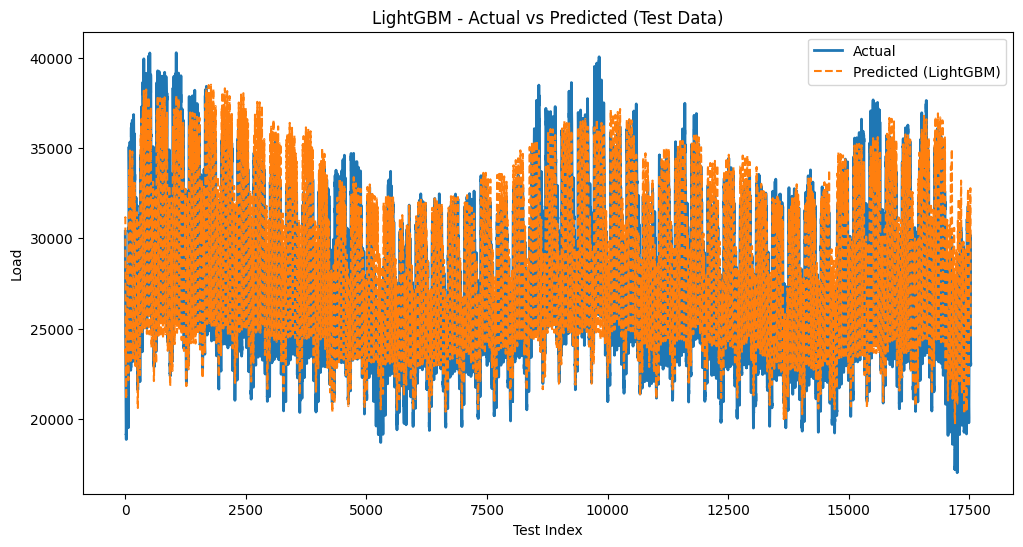

In [13]:
plt.figure(figsize=(12, 6))
plt.plot(y_test.values, label="Actual", linewidth=2)
plt.plot(y_pred, label="Predicted (LightGBM)", linestyle="--")
plt.title("LightGBM - Actual vs Predicted (Test Data)")
plt.xlabel("Test Index")
plt.ylabel("Load")
plt.legend()
plt.show()


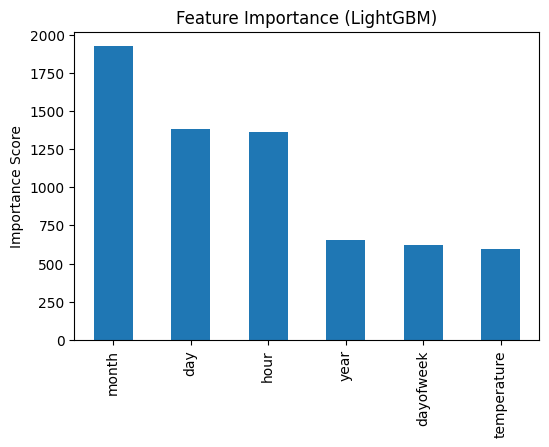

In [14]:
importance = pd.Series(
    lgb_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(6, 4))
importance.plot(kind="bar")
plt.title("Feature Importance (LightGBM)")
plt.ylabel("Importance Score")
plt.show()

Another method - LightXGBoost

In [15]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import lightgbm as lgb
import matplotlib.pyplot as plt


In [16]:
df = pd.read_csv("../data/processed/final_dataset.csv")
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp")
df = df.set_index("timestamp")

target_col = "load_actual"   # change if needed
df[target_col] = df[target_col].astype(float)


In [17]:
# 1 hour lag
df["lag1"] = df[target_col].shift(1)
df["lag24"] = df[target_col].shift(24)    # previous day
df["lag168"] = df[target_col].shift(168)  # previous week

# Drop NaNs created by lag
df = df.dropna()

In [18]:
df["hour"] = df.index.hour
df["dayofweek"] = df.index.dayofweek
df["month"] = df.index.month

In [19]:
features = ["lag1", "lag24", "lag168", "hour", "dayofweek", "month"]

X = df[features]
y = df[target_col]

split = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

In [20]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("Any NaNs in X_train?", X_train.isna().sum().sum())
print("Any NaNs in y_train?", y_train.isna().sum())

X_train shape: (69985, 6)
y_train shape: (69985,)
Any NaNs in X_train? 0
Any NaNs in y_train? 0


In [21]:
from lightgbm import early_stopping, log_evaluation
import lightgbm as lgb

model = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# Training with progress log
print("Training LightGBM model...")
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[
        early_stopping(stopping_rounds=50),
        log_evaluation(period=10)
    ]
)
print("Training completed.")


Training LightGBM model...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.012012 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 809
[LightGBM] [Info] Number of data points in the train set: 69985, number of used features: 6
[LightGBM] [Info] Start training from score 28702.234977
Training until validation scores don't improve for 50 rounds
[10]	valid_0's l2: 8.01548e+06
[20]	valid_0's l2: 3.42662e+06
[30]	valid_0's l2: 1.60496e+06
[40]	valid_0's l2: 897369
[50]	valid_0's l2: 627940
[60]	valid_0's l2: 508020
[70]	valid_0's l2: 447477
[80]	valid_0's l2: 415841
[90]	valid_0's l2: 394246
[100]	valid_0's l2: 377603
[110]	valid_0's l2: 367500
[120]	valid_0's l2: 358218
[130]	valid_0's l2: 349289
[140]	valid_0's l2: 341727
[150]	valid_0's l2: 335770
[160]	valid_0's l2: 331531
[170]	valid_0's l2: 326722
[180]	valid_0's l2: 322776
[190]	valid_0's l2: 318970
[200]	valid_0's l2: 314720
[210]	valid_0's l2: 31

In [22]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
mape = mean_absolute_percentage_error(y_test, y_pred) * 100

print("MAE:", mae)
print("RMSE:", rmse)
print("MAPE:", mape)


MAE: 375.8355839480462
RMSE: 496.1328650842523
MAPE: 1.3376365567177328


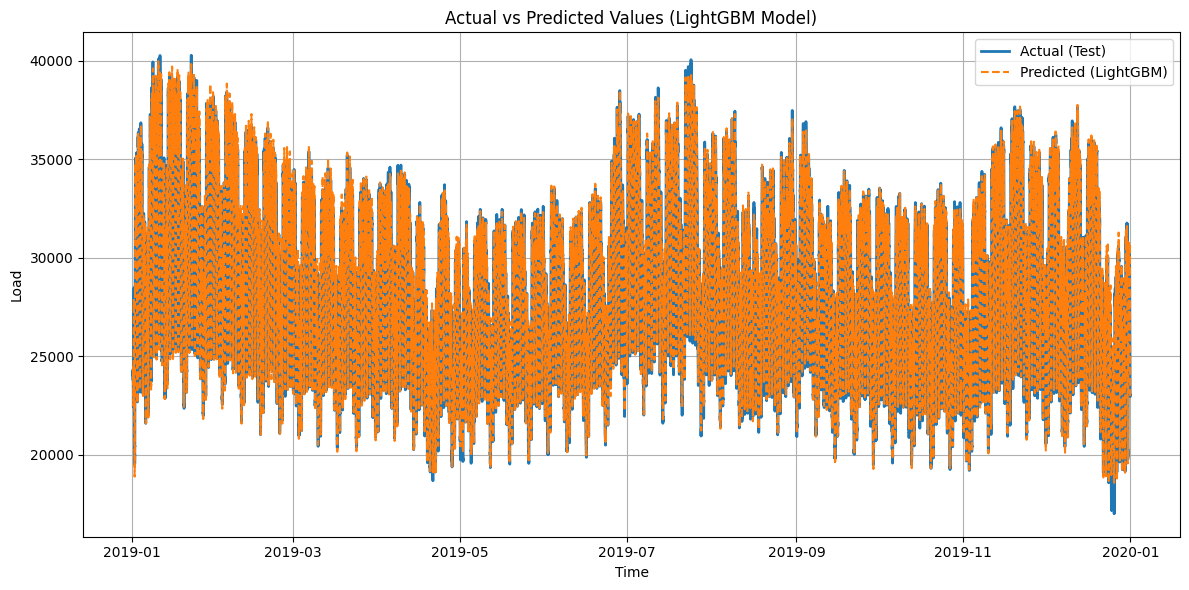

In [23]:
import matplotlib.pyplot as plt

# Plot Actual vs Predicted
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test.values, label="Actual (Test)", linewidth=2)
plt.plot(y_test.index, y_pred, label="Predicted (LightGBM)", linestyle="--")
plt.title("Actual vs Predicted Values (LightGBM Model)")
plt.xlabel("Time")
plt.ylabel("Load")  # change if your target column is something else
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

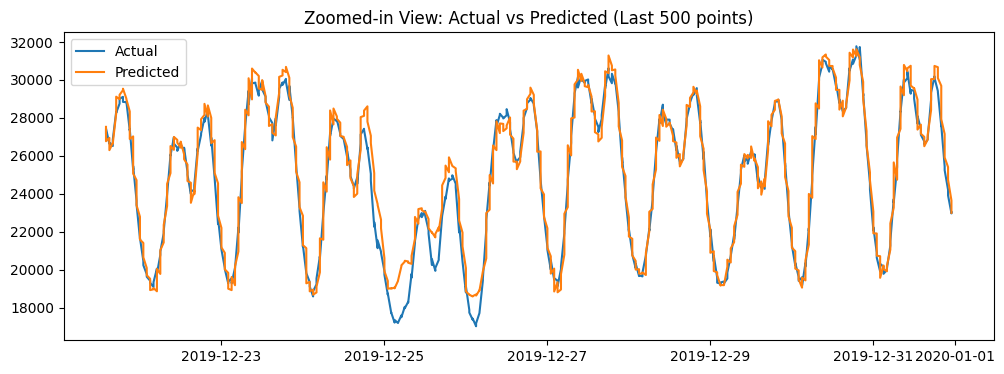

In [24]:
plt.figure(figsize=(12, 4))
plt.plot(y_test.index[-500:], y_test.values[-500:], label="Actual")
plt.plot(y_test.index[-500:], y_pred[-500:], label="Predicted")
plt.title("Zoomed-in View: Actual vs Predicted (Last 500 points)")
plt.legend()
plt.show()

In [25]:
import numpy as np
import pandas as pd

epsilon = 1e-8  # To avoid division by zero
ape = np.abs((y_test.values - y_pred) / (y_test.values + epsilon)) * 100

# Optional: turn into a DataFrame for clarity
error_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred,
    "APE (%)": ape
}, index=y_test.index)

print(error_df.head())


                           Actual     Predicted   APE (%)
timestamp                                                
2019-01-01 11:00:00  23858.000000  23876.578540  0.077871
2019-01-01 12:00:00  24010.877517  23972.665998  0.159143
2019-01-01 12:00:00  24340.000000  24109.706549  0.946152
2019-01-01 13:00:00  23996.153179  24478.396864  2.009671
2019-01-01 13:00:00  24244.000000  24138.400691  0.435569


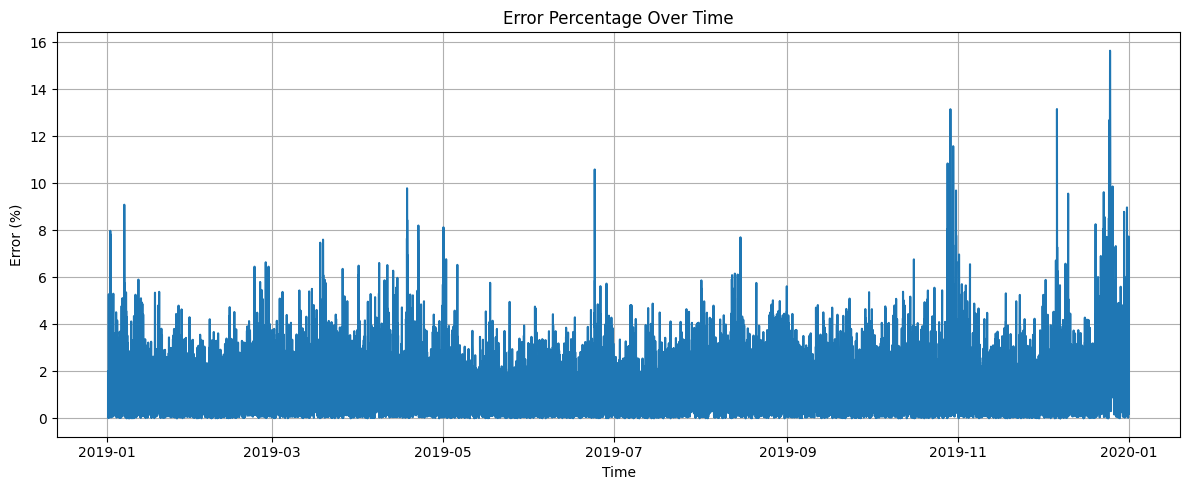

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(y_test.index, ape, label="Absolute Percentage Error (%)")
plt.title("Error Percentage Over Time")
plt.xlabel("Time")
plt.ylabel("Error (%)")
plt.grid(True)
plt.tight_layout()
plt.show()
